In [1]:
# Install Ultralytics.
# The -q flag keeps the output shorter.
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:0000:0100:01


In [2]:
# Core imports used throughout the notebook.
# pathlib makes file paths cleaner than string concatenation.

from pathlib import Path
import os
import random
import yaml
import shutil
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
import kagglehub
from ultralytics import YOLO

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
#KaggleHub downloads the latest available version and returns the local path to the dataset files.

path = kagglehub.dataset_download('vipoooool/new-plant-diseases-dataset')
dataset_download_path = Path(path)

print('Path to dataset files:', dataset_download_path)

Path to dataset files: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset


In [4]:
print('Dataset download path:')
print(dataset_download_path)

print('\nTop-level files/folders:')
for p in sorted(dataset_download_path.iterdir()):
    print('-', p.name)

print('\nCommon nested folders to check:')
possible_nested_roots = [
    dataset_download_path / 'New Plant Diseases Dataset(Augmented)' / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'new plant diseases dataset(augmented)' / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'new plant diseases dataset(augmented)',
]

for root in possible_nested_roots:
    print(root, '->', root.exists())

Dataset download path:
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset

Top-level files/folders:
- New Plant Diseases Dataset(Augmented)
- new plant diseases dataset(augmented)
- test

Common nested folders to check:
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented) -> True
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented) -> True
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented) -> True
/kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/new plant diseases dataset(augmented) -> True


In [5]:
def show_tree(root, max_depth=4, max_items=30):
    root = Path(root)
    count = 0
    for p in sorted(root.rglob('*')):
        depth = len(p.relative_to(root).parts)
        if depth <= max_depth:
            print('  ' * depth + p.name)
            count += 1
            if count >= max_items:
                print('...')
                break

show_tree(dataset_download_path)

  New Plant Diseases Dataset(Augmented)
    New Plant Diseases Dataset(Augmented)
      train
        Apple___Apple_scab
        Apple___Black_rot
        Apple___Cedar_apple_rust
        Apple___healthy
        Blueberry___healthy
        Cherry_(including_sour)___Powdery_mildew
        Cherry_(including_sour)___healthy
        Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
        Corn_(maize)___Common_rust_
        Corn_(maize)___Northern_Leaf_Blight
        Corn_(maize)___healthy
        Grape___Black_rot
        Grape___Esca_(Black_Measles)
        Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
        Grape___healthy
        Orange___Haunglongbing_(Citrus_greening)
        Peach___Bacterial_spot
        Peach___healthy
        Pepper,_bell___Bacterial_spot
        Pepper,_bell___healthy
        Potato___Early_blight
        Potato___Late_blight
        Potato___healthy
        Raspberry___healthy
        Soybean___healthy
        Squash___Powdery_mildew
        Strawberry___Leaf_

In [6]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


dataset_root_candidates = [
    dataset_download_path / 'New Plant Diseases Dataset(Augmented)' / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'new plant diseases dataset(augmented)' / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'New Plant Diseases Dataset(Augmented)',
    dataset_download_path / 'new plant diseases dataset(augmented)',
    dataset_download_path,
]

dataset_root = None
for candidate in dataset_root_candidates:
    if (candidate / 'train').exists() and (candidate / 'valid').exists():
        dataset_root = candidate
        break

assert dataset_root is not None, 'Could not find train/valid folders. Check the printed candidate paths above.'

train_dir = dataset_root / 'train'
val_dir = dataset_root / 'valid'

train_classes = [p for p in train_dir.iterdir() if p.is_dir()]
val_classes = [p for p in val_dir.iterdir() if p.is_dir()]

print('Selected dataset_root:', dataset_root)
print('Train exists:', train_dir.exists())
print('Valid exists:', val_dir.exists())
print('Number of train classes:', len(train_classes))
print('Number of valid classes:', len(val_classes))
print('\nFirst 10 train classes:')
for class_dir in sorted(train_classes)[:10]:
    print('-', class_dir.name)

Selected dataset_root: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Train exists: True
Valid exists: True
Number of train classes: 38
Number of valid classes: 38

First 10 train classes:
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy
- Cherry_(including_sour)___Powdery_mildew
- Cherry_(including_sour)___healthy
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight


In [7]:
WORK_DATASET = Path('/kaggle/working/plant_disease_cls_dataset')

if WORK_DATASET.exists():
    shutil.rmtree(WORK_DATASET)

WORK_DATASET.mkdir(parents=True, exist_ok=True)

def link_or_copy(src, dst):
    src = Path(src)
    dst = Path(dst)
    try:
        dst.symlink_to(src, target_is_directory=True)
    except Exception:
        shutil.copytree(src, dst)

link_or_copy(train_dir, WORK_DATASET / 'train')
link_or_copy(val_dir, WORK_DATASET / 'val')

print('YOLO classification dataset root:', WORK_DATASET)
print('Contains:', [p.name for p in WORK_DATASET.iterdir()])

YOLO classification dataset root: /kaggle/working/plant_disease_cls_dataset
Contains: ['val', 'train']


In [8]:
def count_images_by_class(split_dir):
    rows = []
    for class_dir in sorted(Path(split_dir).iterdir()):
        if class_dir.is_dir():
            n = sum(1 for p in class_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS)
            rows.append({'class': class_dir.name, 'images': n})
    return pd.DataFrame(rows)

train_counts = count_images_by_class(WORK_DATASET / 'train')
val_counts = count_images_by_class(WORK_DATASET / 'val')

print('Number of classes:', len(train_counts))
display(train_counts.head())
display(train_counts.describe())

Number of classes: 38


,class,images
0,Apple___Apple_scab,2016
1,Apple___Black_rot,1987
2,Apple___Cedar_apple_rust,1760
3,Apple___healthy,2008
4,Blueberry___healthy,1816


,images
count,38.000000
mean,1849.868421
std,105.724315
min,1642.000000
25%,1763.500000
50%,1844.500000
75%,1924.500000
max,2022.000000


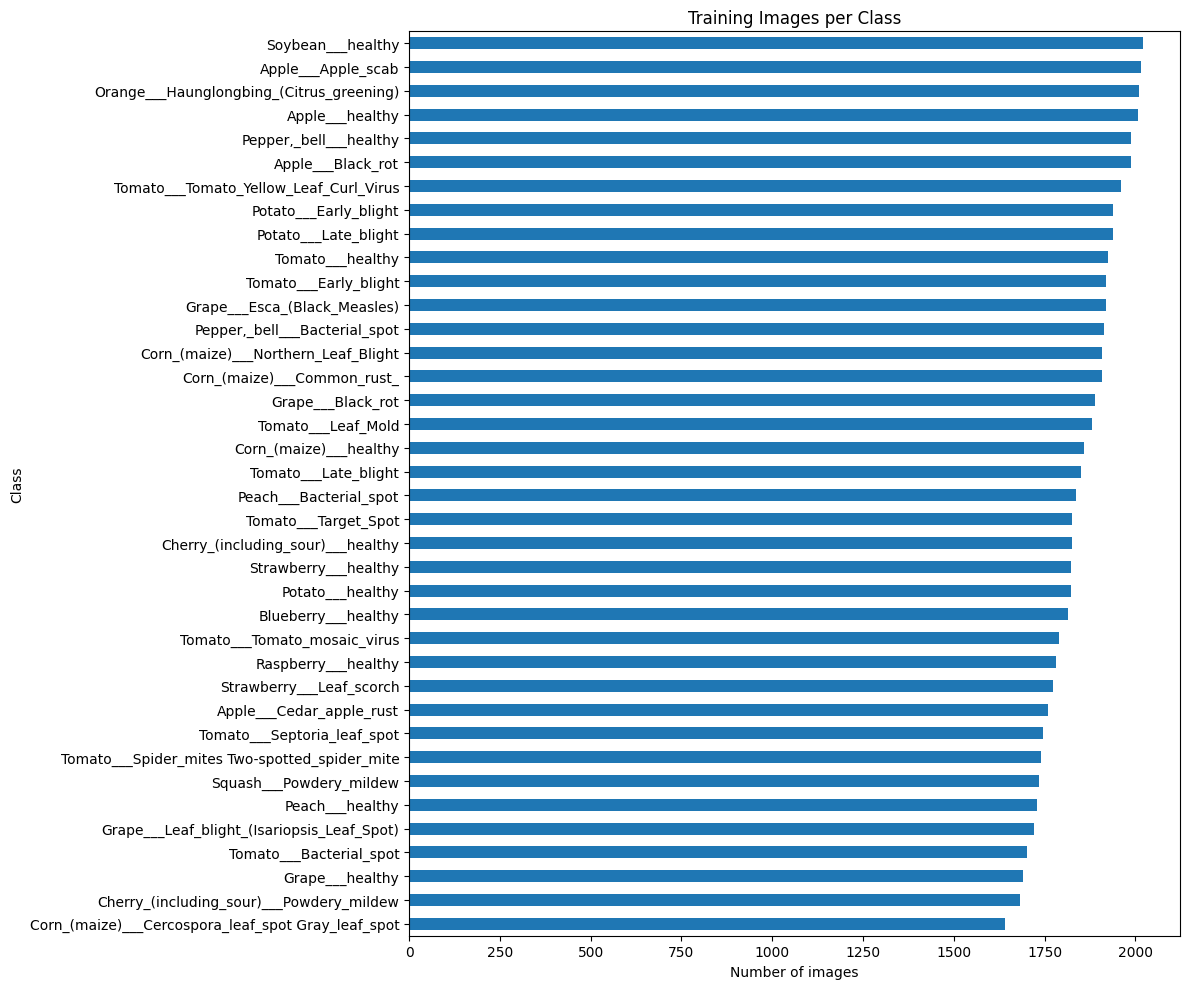

In [9]:
plt.figure(figsize=(12, 10))
train_counts.sort_values('images').plot(kind='barh', x='class', y='images', legend=False, ax=plt.gca())
plt.title('Training Images per Class')
plt.xlabel('Number of images')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

In [10]:
from PIL import Image
import random
import matplotlib.pyplot as plt

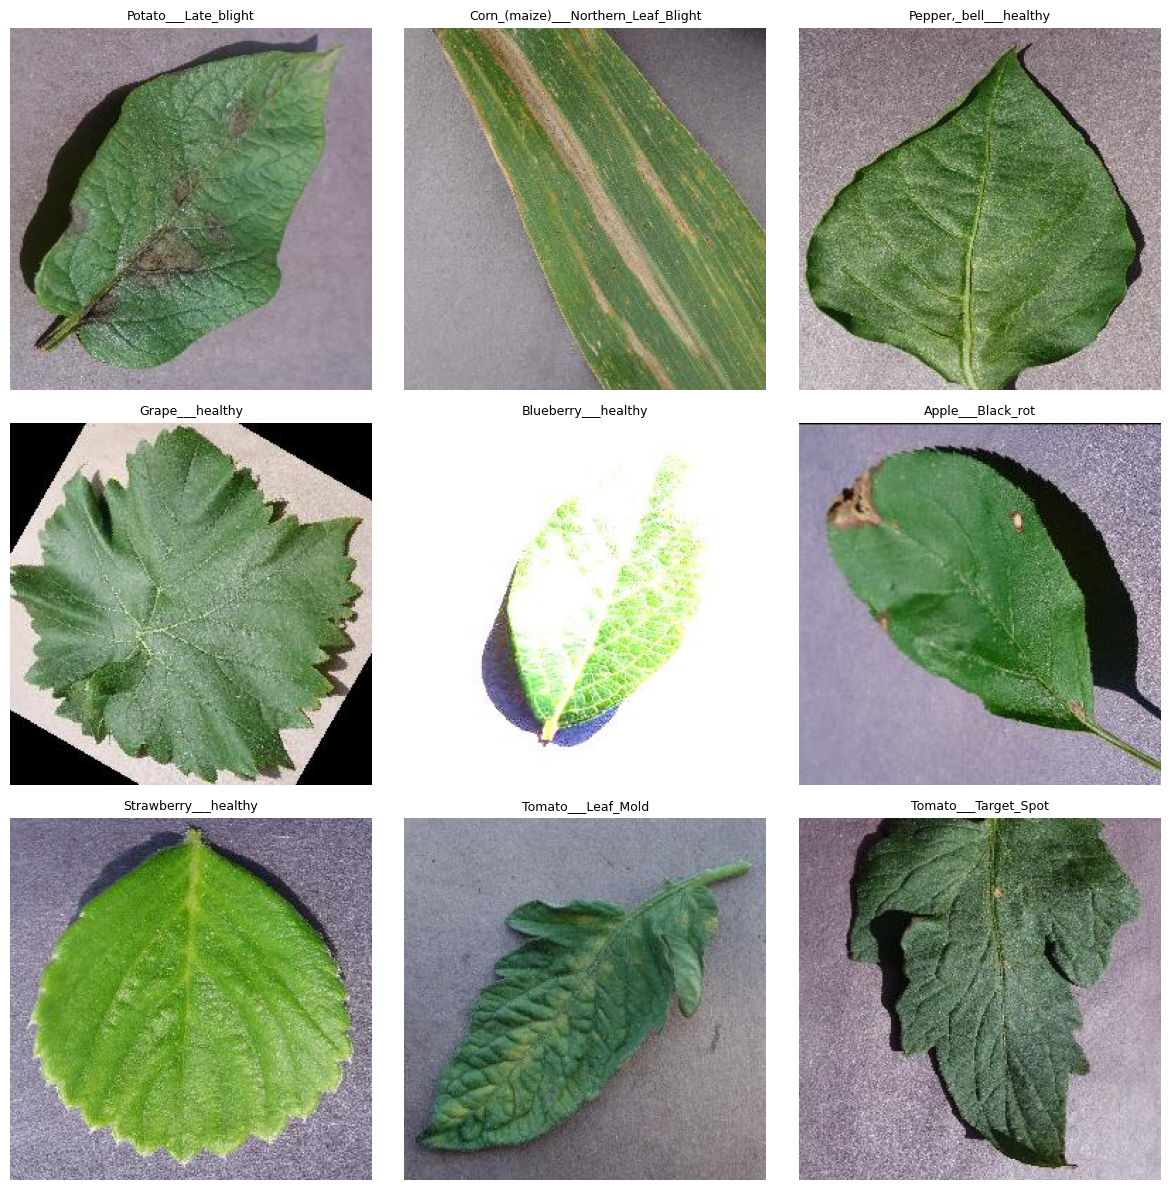

In [11]:
class_dirs = [p for p in (WORK_DATASET / "train").iterdir() if p.is_dir()]
sample_classes = random.sample(class_dirs, min(9, len(class_dirs)))

plt.figure(figsize=(12, 12))

for i, class_dir in enumerate(sample_classes):
    images = [p for p in class_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS]

    if not images:
        print("No images found in:", class_dir)
        continue

    img_path = random.choice(images)
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_dir.name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# # Smoke test: one epoch only.

# model = YOLO('yolo11n-cls.pt')

# smoke_results = model.train(
#     data=str(WORK_DATASET),
#     epochs=1,
#     imgsz=224,
#     batch=32,
#     project='/kaggle/working/runs',
#     name='plant_disease_yolo11_cls_smoke',
#     exist_ok=True
# )

In [13]:

# # Full training with early stopping.
# # epochs=50 is only the maximum number of epochs.
# # patience=5 means: stop if validation performance does not improve for 5 epochs.
# # save=True keeps best.pt and last.pt.
# # save_period=1 saves an extra checkpoint for every epoch, such as epoch1.pt, epoch2.pt, etc.


# RUN_FULL_TRAINING = True

# if RUN_FULL_TRAINING:
#     model = YOLO('yolo11n-cls.pt')
#     train_results = model.train(
#         data=str(WORK_DATASET),
#         epochs=50,
#         imgsz=224,
#         batch=32,
#         patience=5,
#         save=True,
#         save_period=1,
#         project='/kaggle/working/runs',
#         name='plant_disease_yolo11n_cls_earlystop',
#         exist_ok=True
#     )
# else:
#     print('Full training is disabled. Set RUN_FULL_TRAINING = True when ready.')

In [14]:

# This is still a real fine-tuning run from pretrained YOLO11 classification weights.
# We are not trying to fake a lower score. We are using regularization to reduce overfitting risk.

RUN_REGULARIZED_FINETUNE = True

if RUN_REGULARIZED_FINETUNE:
    model = YOLO('yolo11n-cls.pt')
    finetune_results = model.train(
        data=str(WORK_DATASET),
        epochs=50,
        imgsz=224,
        batch=32,
        patience=5,
        lr0=0.001,
        lrf=0.01,
        weight_decay=0.001,
        dropout=0.2,
        cos_lr=True,
        save=True,
        save_period=1,
        project='/kaggle/working/runs',
        name='plant_disease_yolo11n_cls_regularized_finetune',
        exist_ok=True
    )
else:
    print('Regularized fine-tuning is disabled. Set RUN_REGULARIZED_FINETUNE = True if you want to run it.')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/plant_disease_cls_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plant_disease_yolo11n_cls_regularized_finetune, nbs=64, nms=False, opset=None, optimize

In [15]:
# import os
# import shutil
# from IPython.display import FileLink

# zip_path = "/kaggle/working/working_folder.zip"

# if os.path.exists(zip_path):
#     os.remove(zip_path)

# shutil.make_archive("/kaggle/working/working_folder", "zip", "/kaggle/working")

# FileLink("/kaggle/working/working_folder.zip")

In [16]:
SMOKE_WEIGHTS = Path('/kaggle/working/runs/plant_disease_yolo11_cls_smoke/weights/best.pt')
FULL_WEIGHTS = Path('/kaggle/working/runs/plant_disease_yolo11n_cls_earlystop/weights/best.pt')
REGULARIZED_WEIGHTS = Path('/kaggle/working/runs/plant_disease_yolo11n_cls_regularized_finetune/weights/best.pt')

# if REGULARIZED_WEIGHTS.exists():
#     BEST_WEIGHTS = REGULARIZED_WEIGHTS
# elif FULL_WEIGHTS.exists():
#     BEST_WEIGHTS = FULL_WEIGHTS
# else:
#     BEST_WEIGHTS = SMOKE_WEIGHTS
BEST_WEIGHTS = REGULARIZED_WEIGHTS
print('Using weights:', BEST_WEIGHTS)

trained_model = YOLO(str(BEST_WEIGHTS))
metrics = trained_model.val(data=str(WORK_DATASET), imgsz=224)

print('Top-1 accuracy:', metrics.top1)
print('Top-5 accuracy:', metrics.top5)

Using weights: /kaggle/working/runs/plant_disease_yolo11n_cls_regularized_finetune/weights/best.pt
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,574,702 parameters, 0 gradients, 3.2 GFLOPs
train: /kaggle/working/plant_disease_cls_dataset/train... found 70295 images in 38 classes ✅ 
val: /kaggle/working/plant_disease_cls_dataset/val... found 17572 images in 38 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.1±3.1 MB/s, size: 12.1 KB)
val: Scanning /kaggle/working/plant_disease_cls_dataset/val... 17572 images, 0 corrupt: 100% ━━━━━━━━━━━━ 17572/17572 6.1Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 1099/1099 25.6it/s 42.9s<0.0s
                   all      0.994          1
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val
Top-1 accuracy: 0.9939676523208618
Top-5 accuracy:

Run directory: /kaggle/working/runs/plant_disease_yolo11n_cls_regularized_finetune


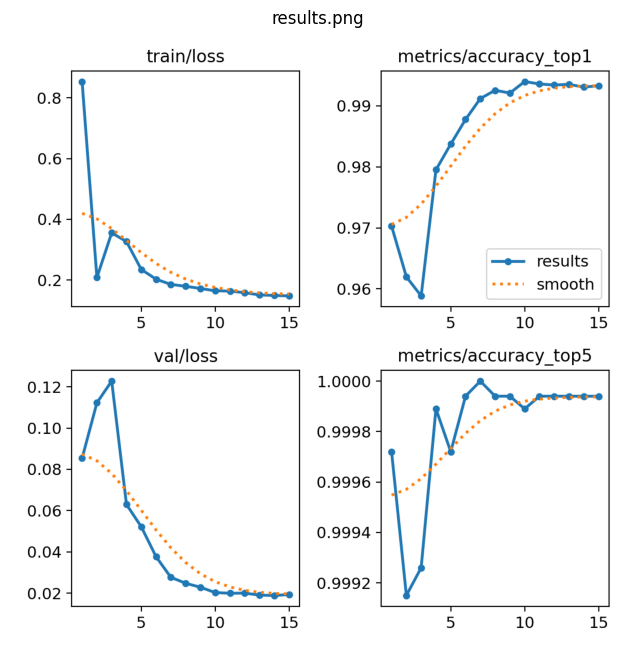

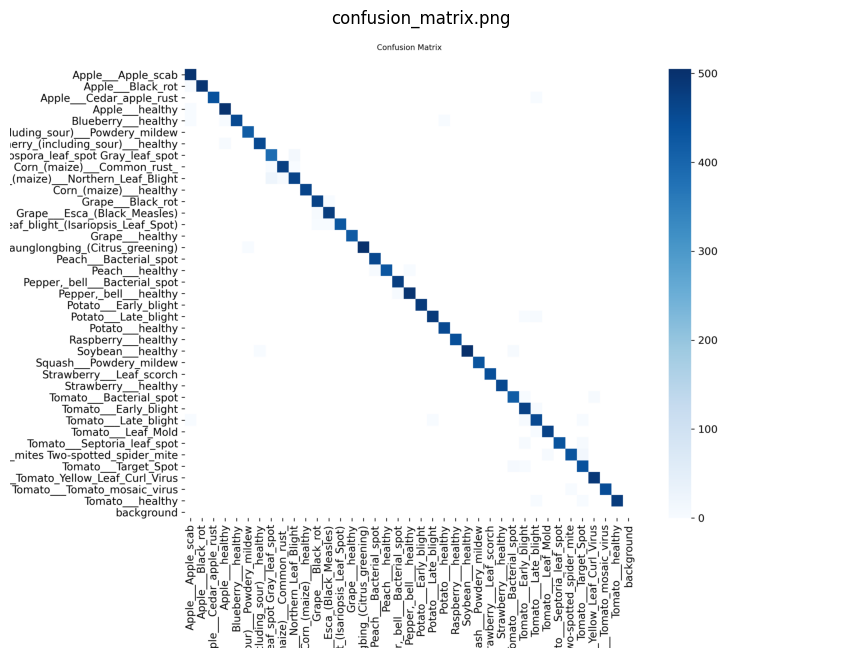

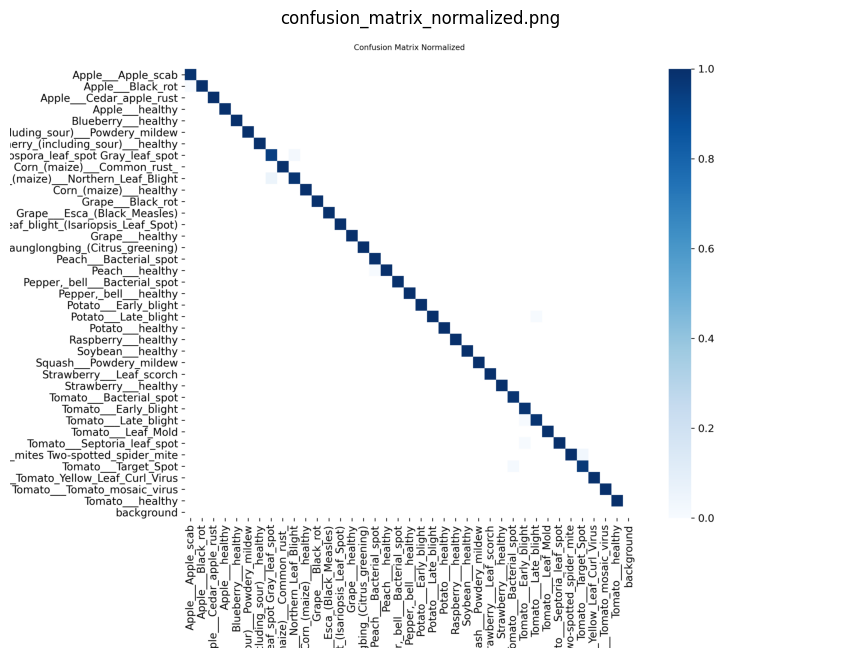

In [17]:
run_dir = BEST_WEIGHTS.parent.parent
print('Run directory:', run_dir)

for filename in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']:
    img_path = run_dir / filename
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(filename)
        plt.axis('off')
        plt.show()
    else:
        print('Not found:', img_path)

In [18]:
val_images = [p for p in (WORK_DATASET / 'val').rglob('*') if p.suffix.lower() in IMAGE_EXTS]
sample_images = random.sample(val_images, min(9, len(val_images)))

results = trained_model.predict(sample_images, imgsz=224)

plt.figure(figsize=(12, 12))
for i, result in enumerate(results):
    img = Image.open(result.path).convert('RGB')
    pred_id = int(result.probs.top1)
    pred_name = result.names[pred_id]
    confidence = float(result.probs.top1conf)
    true_name = Path(result.path).parent.name

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f'True: {true_name}\nPred: {pred_name} ({confidence:.2f})', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


0: 224x224 Pepper,_bell___healthy 1.00, Pepper,_bell___Bacterial_spot 0.00, Potato___healthy 0.00, Soybean___healthy 0.00, Cherry_(including_sour)___healthy 0.00, 3.4ms
1: 224x224 Potato___healthy 0.99, Potato___Late_blight 0.01, Soybean___healthy 0.00, Potato___Early_blight 0.00, Cherry_(including_sour)___healthy 0.00, 3.4ms
2: 224x224 Squash___Powdery_mildew 1.00, Apple___healthy 0.00, Tomato___healthy 0.00, Grape___Leaf_blight_(Isariopsis_Leaf_Spot) 0.00, Tomato___Bacterial_spot 0.00, 3.4ms
3: 224x224 Grape___Leaf_blight_(Isariopsis_Leaf_Spot) 1.00, Grape___healthy 0.00, Squash___Powdery_mildew 0.00, Grape___Black_rot 0.00, Grape___Esca_(Black_Measles) 0.00, 3.4ms
4: 224x224 Raspberry___healthy 1.00, Strawberry___healthy 0.00, Cherry_(including_sour)___healthy 0.00, Soybean___healthy 0.00, Potato___healthy 0.00, 3.4ms
5: 224x224 Corn_(maize)___Northern_Leaf_Blight 1.00, Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 0.00, Potato___Late_blight 0.00, Tomato___Late_blight 0.00, To

FileNotFoundError: [Errno 2] No such file or directory: 'image0.jpg'

<Figure size 1200x1200 with 0 Axes>

In [19]:
OUTPUT_ZIP = '/kaggle/working/plant_disease_yolo11_cls_outputs'
shutil.make_archive(OUTPUT_ZIP, 'zip', '/kaggle/working/runs')
print('Created:', OUTPUT_ZIP + '.zip')

Created: /kaggle/working/plant_disease_yolo11_cls_outputs.zip


In [20]:
import shutil
from IPython.display import FileLink, display

OUTPUT_ZIP = "/kaggle/working/plant_disease_yolo11_cls_outputs"

shutil.make_archive(
    OUTPUT_ZIP,
    "zip",
    "/kaggle/working/runs"
)

zip_path = OUTPUT_ZIP + ".zip"

print("Created:", zip_path)
display(FileLink(zip_path))

Created: /kaggle/working/plant_disease_yolo11_cls_outputs.zip


/kaggle/working/plant_disease_yolo11_cls_outputs.zip

In [21]:
import os

print("Does /kaggle/working/runs exist?", os.path.exists("/kaggle/working/runs"))
print("Files in /kaggle/working:")
print(os.listdir("/kaggle/working"))

Does /kaggle/working/runs exist? True
Files in /kaggle/working:
['yolo26n.pt', 'plant_disease_yolo11_cls_outputs.zip', '.virtual_documents', 'yolo11n-cls.pt', 'runs', 'plant_disease_cls_dataset']


In [22]:
import os
import shutil
from IPython.display import FileLink, display

source_dir = "/kaggle/working/runs"
output_base = "/kaggle/working/plant_disease_yolo11_cls_outputs"
zip_path = output_base + ".zip"

# Check source folder
if not os.path.exists(source_dir):
    raise FileNotFoundError(f"Source folder not found: {source_dir}")

# Remove old zip if it exists
if os.path.exists(zip_path):
    os.remove(zip_path)

# Create zip
created_zip = shutil.make_archive(output_base, "zip", source_dir)

print("Created zip:", created_zip)
print("Zip exists:", os.path.exists(zip_path))
print("Zip size MB:", round(os.path.getsize(zip_path) / (1024 * 1024), 2))

display(FileLink(zip_path))

Created zip: /kaggle/working/plant_disease_yolo11_cls_outputs.zip
Zip exists: True
Zip size MB: 137.05


/kaggle/working/plant_disease_yolo11_cls_outputs.zip

In [23]:
!ls -lh /kaggle/working

total 148M
drwxr-xr-x 2 root root 4.0K May 18 11:01 plant_disease_cls_dataset
-rw-r--r-- 1 root root 138M May 18 13:11 plant_disease_yolo11_cls_outputs.zip
drwxr-xr-x 4 root root 4.0K May 18 12:28 runs
-rw-r--r-- 1 root root 5.6M May 18 10:56 yolo11n-cls.pt
-rw-r--r-- 1 root root 5.3M May 18 10:57 yolo26n.pt


In [24]:
import os
import shutil
from IPython.display import FileLink, display

os.makedirs("/kaggle/working/downloads", exist_ok=True)

src = "/kaggle/working/plant_disease_yolo11_cls_outputs.zip"
dst = "/kaggle/working/downloads/plant_disease_yolo11_cls_outputs.zip"

shutil.copy(src, dst)

print("Copied to:", dst)
print("Size MB:", round(os.path.getsize(dst) / (1024 * 1024), 2))

display(FileLink(dst))

Copied to: /kaggle/working/downloads/plant_disease_yolo11_cls_outputs.zip
Size MB: 137.05


/kaggle/working/downloads/plant_disease_yolo11_cls_outputs.zip

In [25]:
from IPython.display import HTML, display

zip_path = "/kaggle/working/plant_disease_yolo11_cls_outputs.zip"

display(HTML(f"""
<a href="files/{zip_path.replace('/kaggle/working/', '')}" download>
    <button style="padding:10px 18px; font-size:16px;">
        Download ZIP
    </button>
</a>
"""))